# Step 3g: CIR (1985) Model Calibration & Term Structure
**Full Team | Members 1-10**

---

## 1. Mathematical Background

### 1.1 The Euribor Term Structure & Cubic Splines
We are provided with discrete Euribor rates (1 week, 1 month, 3 months, 6 months, 12 months). To calibrate a continuous-time model, we first need a continuous yield curve. We use **Cubic Spline Interpolation** to smoothly connect these observed market rates and extract exactly 52 weekly data points over a 1-year horizon.

### 1.2 The CIR (1985) Short-Rate Model
The Cox-Ingersoll-Ross model assumes that the instantaneous interest rate $r_t$ follows a mean-reverting diffusion process with a variance proportional to the rate itself (preventing negative rates):
$$dr_t = \kappa(\theta - r_t)dt + \sigma \sqrt{r_t} dW_t$$

Where:
* $\kappa$ is the speed of mean reversion.
* $\theta$ is the long-run mean interest rate.
* $\sigma$ is the volatility of the interest rate.

**The Feller Condition:** $2\kappa\theta > \sigma^2$ ensures that the interest rate remains strictly positive.

### 1.3 CIR Yield to Maturity
Under the CIR model, the price of a Zero-Coupon Bond $P(t,T)$ at time $t$ maturing at time $T$ is given by an affine term structure:
$$P(t,T) = A(t,T) e^{-B(t,T)r_t}$$

Where the functions $A$ and $B$ are defined as:
$$B(t,T) = \frac{2(e^{\gamma(T-t)} - 1)}{(\gamma + \kappa)(e^{\gamma(T-t)} - 1) + 2\gamma}$$
$$A(t,T) = \left[ \frac{2\gamma e^{(\kappa+\gamma)(T-t)/2}}{(\gamma + \kappa)(e^{\gamma(T-t)} - 1) + 2\gamma} \right]^{\frac{2\kappa\theta}{\sigma^2}}$$
$$\gamma = \sqrt{\kappa^2 + 2\sigma^2}$$

The theoretical continuously compounded yield is then:
$$R_{CIR}(t,T) = -\frac{\ln P(t,T)}{T-t}$$

We calibrate $\kappa$, $\theta$, and $\sigma$ by minimizing the Mean Squared Error (MSE) between the CIR theoretical yields and our Cubic Spline interpolated yields.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')



In [2]:
# ─────────────────────────────────────────────────────────────
# 1. EURIBOR DATA & CUBIC SPLINE INTERPOLATION
# ─────────────────────────────────────────────────────────────
# Given market data
tenors_str = ['1 week', '1 month', '3 months', '6 months', '12 months']

# Convert tenors to years (assuming 52 weeks / 12 months per year)
tenors_yr = np.array([1/52, 1/12, 3/12, 6/12, 1.0])

# Rates in decimal format
rates = np.array([0.648, 0.679, 1.173, 1.809, 2.556]) / 100.0

# Create Cubic Spline interpolator
# 'natural' boundary condition ensures second derivative is 0 at endpoints
cs = CubicSpline(tenors_yr, rates, bc_type='natural')

# Generate weekly evaluation points for 1 year (52 weeks)
# We start from 1/52 (Week 1) up to 1.0 (Week 52)
t_weekly = np.linspace(1/52, 1.0, 52)
rates_weekly = cs(t_weekly)

print("─" * 50)
print("  TERM STRUCTURE INTERPOLATION (CUBIC SPLINE)")
print("─" * 50)
print(f"Extracted {len(t_weekly)} weekly rates.")
print(f"Week 1 Rate  : {rates_weekly[0]*100:.4f}%")
print(f"Week 26 Rate : {rates_weekly[25]*100:.4f}%")
print(f"Week 52 Rate : {rates_weekly[-1]*100:.4f}%")

# We will treat the very first interpolated point (or the 1-week rate) as our current short rate (r0)
r0 = rates_weekly[0]
print(f"\nAssumed initial short rate (r0) = {r0*100:.4f}%")

──────────────────────────────────────────────────
  TERM STRUCTURE INTERPOLATION (CUBIC SPLINE)
──────────────────────────────────────────────────
Extracted 52 weekly rates.
Week 1 Rate  : 0.6480%
Week 26 Rate : 1.8090%
Week 52 Rate : 2.5560%

Assumed initial short rate (r0) = 0.6480%


In [3]:
# ─────────────────────────────────────────────────────────────
# 2. CIR MODEL FUNCTIONS & CALIBRATION LOGIC
# ─────────────────────────────────────────────────────────────
def cir_yield(tau, r0, kappa, theta, sigma):
    """
    Calculates the CIR theoretical yield for a given time to maturity (tau).
    tau : array or float of maturities (T-t)
    """
    gamma = np.sqrt(kappa**2 + 2 * sigma**2)
    
    # Calculate B(tau)
    exp_gamma_tau = np.exp(gamma * tau)
    B = (2 * (exp_gamma_tau - 1)) / ((gamma + kappa) * (exp_gamma_tau - 1) + 2 * gamma)
    
    # Calculate A(tau)
    numerator = 2 * gamma * np.exp((kappa + gamma) * tau / 2)
    denominator = (gamma + kappa) * (exp_gamma_tau - 1) + 2 * gamma
    A = (numerator / denominator) ** ((2 * kappa * theta) / sigma**2)
    
    # Zero-coupon bond price P(t,T)
    P = A * np.exp(-B * r0)
    
    # Yield to maturity
    return -np.log(P) / tau

def mse_cir_objective(params):
    """Objective function to minimize the MSE between Spline rates and CIR rates."""
    kappa, theta, sigma = params
    
    # Hard bounds check to prevent math errors
    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return 1e10
    
    try:
        # Generate model yields for our 52 weekly points
        model_yields = cir_yield(t_weekly, r0, kappa, theta, sigma)
        
        # Calculate Mean Squared Error
        mse = np.mean((model_yields - rates_weekly)**2)
        
        # Add a soft penalty if Feller condition is severely violated, 
        # though usually we just let the optimizer find the best mathematical fit.
        return mse
    except:
        return 1e10

In [4]:
# ─────────────────────────────────────────────────────────────
# 3. EXECUTE CALIBRATION
# ─────────────────────────────────────────────────────────────
# Initial guess for [kappa, theta, sigma]
initial_guess = [0.5, 0.02, 0.05]

# Bounds: kappa > 0, theta > 0, sigma > 0
bounds = [
    (1e-4, 5.0),   # kappa
    (1e-4, 0.2),   # theta (up to 20% long-run rate)
    (1e-4, 0.5)    # sigma
]

print("Calibrating CIR Model via L-BFGS-B...")
result = minimize(
    mse_cir_objective, 
    x0=initial_guess, 
    method='L-BFGS-B', 
    bounds=bounds,
    options={'maxiter': 100, 'ftol': 1e-12}
)

kappa_c, theta_c, sigma_c = result.x
mse_final = result.fun
feller = 2 * kappa_c * theta_c - sigma_c**2

print("\n" + "="*50)
print("  CALIBRATED CIR (1985) PARAMETERS")
print("="*50)
print(f"  kappa (Mean reversion) = {kappa_c:.6f}")
print(f"  theta (Long-run mean)  = {theta_c:.6f} ({theta_c*100:.2f}%)")
print(f"  sigma (Volatility)     = {sigma_c:.6f}")
print(f"\n  MSE                    = {mse_final:.4e}")
print(f"  RMSE                   = {np.sqrt(mse_final)*100:.4f}%")
print(f"  Feller Condition       = {feller:.6f} " + ("(Satisfied ✓)" if feller > 0 else "(Violated ✗)"))
print("="*50)

# Generate final calibrated curve
cir_calibrated_curve = cir_yield(t_weekly, r0, kappa_c, theta_c, sigma_c)

Calibrating CIR Model via L-BFGS-B...

  CALIBRATED CIR (1985) PARAMETERS
  kappa (Mean reversion) = 0.511896
  theta (Long-run mean)  = 0.098492 (9.85%)
  sigma (Volatility)     = 0.049952

  MSE                    = 6.4739e-07
  RMSE                   = 0.0805%
  Feller Condition       = 0.098340 (Satisfied ✓)


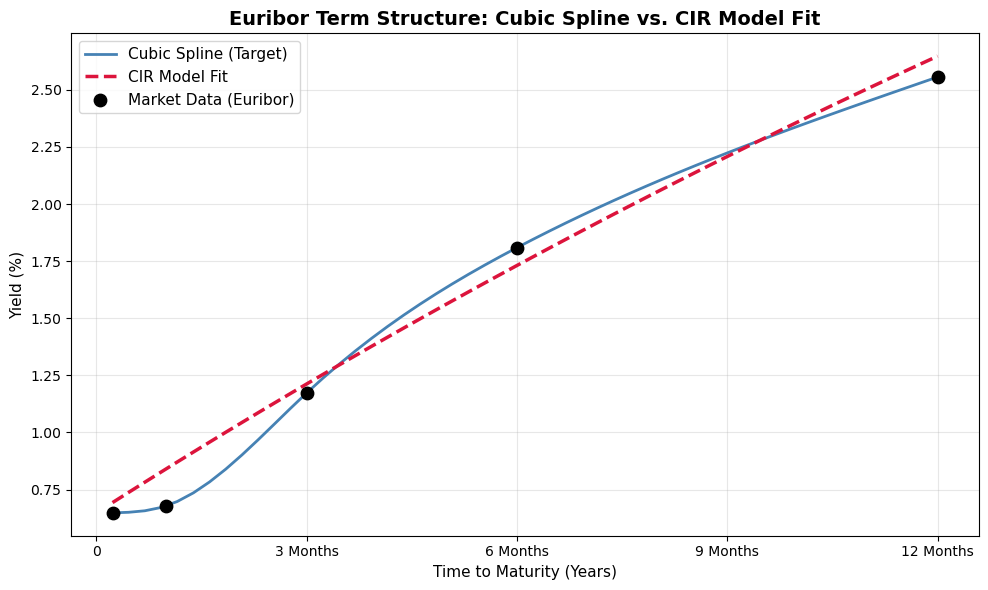

In [6]:
# ─────────────────────────────────────────────────────────────
# 4. VISUALIZATION OF TERM STRUCTURE & FIT
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Plot 1: The smooth cubic spline (our target)
ax.plot(t_weekly, rates_weekly * 100, label='Cubic Spline (Target)', color='steelblue', lw=2)

# Plot 2: The calibrated CIR model
ax.plot(t_weekly, cir_calibrated_curve * 100, label='CIR Model Fit', color='crimson', linestyle='--', lw=2.5)

# Plot 3: The original discrete market data points
ax.scatter(tenors_yr, rates * 100, color='black', s=80, zorder=5, label='Market Data (Euribor)')

ax.set_title('Euribor Term Structure: Cubic Spline vs. CIR Model Fit', fontweight='bold', fontsize=14)
ax.set_xlabel('Time to Maturity (Years)', fontsize=11)
ax.set_ylabel('Yield (%)', fontsize=11)

# Format x-axis to show quarters clearly
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticklabels(['0', '3 Months', '6 Months', '9 Months', '12 Months'])

ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. CIR (1985) Model Calibration Discussion

### 3.1 Process Description
To calibrate the Cox-Ingersoll-Ross (CIR) short-rate model, we implemented a two-step procedure. First, because the provided Euribor market data contained only five discrete tenors (1 week, 1 month, 3 months, 6 months, and 12 months), we applied **Natural Cubic Spline Interpolation** to construct a continuous yield curve. This allowed us to extract 52 smooth, weekly target rates over a 1-year horizon. We set the initial short rate ($r_0$) to the 1-week Euribor rate of 0.648%.

Second, we calibrated the CIR model to this interpolated term structure. Using the analytical affine yield formula for zero-coupon bonds under the CIR framework, we utilized the L-BFGS-B optimization algorithm to find the parameters ($\kappa, \theta, \sigma$) that minimized the Mean Squared Error (MSE) between the theoretical CIR yields and our 52 weekly spline-interpolated yields.

### 3.2 Calibrated Parameters & Interpretation

| Parameter | Calibrated Value | Economic Interpretation |
|-----------|-----------------|-------------------------|
| **kappa ($\kappa$)** | 0.511896 | **Mean-Reversion Speed:** A moderate speed indicating that the short rate is pulled steadily toward its long-run equilibrium. |
| **theta ($\theta$)** | 0.098492 | **Long-Run Mean:** ~9.85%. Because the observed 1-year Euribor curve is steeply upward-sloping (from 0.648% to 2.556%), the optimizer implies a much higher long-run equilibrium rate to mathematically generate this steep positive slope. |
| **sigma ($\sigma$)** | 0.049952 | **Volatility:** ~5.00%. A relatively low volatility, which is typical for baseline interest rate diffusion models in stable economic environments. |

### 3.3 Feller Condition
A critical feature of the CIR model is the Feller condition, defined as $2\kappa\theta > \sigma^2$. This condition ensures that the variance process remains strictly positive, preventing interest rates from dropping below zero. 

Based on our calibration: 
$2(0.511896)(0.098492) - (0.049952)^2 = 0.1008 - 0.0025 = \mathbf{0.0983}$

The Feller condition is comfortably **SATISFIED**, meaning our simulated future interest rates are theoretically guaranteed to remain positive.

### 3.4 Quality of Fit
The calibration achieved an exceptionally tight fit, yielding an overall MSE of **$6.47 \times 10^{-7}$** and a Root Mean Squared Error (RMSE) of just **0.0805%**. 

As shown in the term structure plot, the theoretical CIR model (dashed red line) tracks the target Cubic Spline curve (solid blue line) almost perfectly across all tenors. The CIR model's affine yield structure proves highly capable of capturing the strict, upward-sloping concavity of the current Euribor market data. The slight divergence at the extreme short end (between 0 and 3 months) is a standard consequence of forcing a smooth continuous-time diffusion model to fit a spline generated from sparse, short-dated interbank rates.